### Step 1: Import Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

### Step 2: Download NLTK Resources

In [13]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\skaar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\skaar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\skaar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### Step 3: Load Dataset

In [14]:
df = pd.read_csv("coretech_feedback.csv")
df.head()

,Feedback_ID,Client_Name,Service,Feedback_Text,Rating,Sentiment
0,1,Ali,Web Development,Excellent service and fast delivery,5,Positive
1,2,Sara,SEO,Very professional team and great support,5,Positive
2,3,Ahmed,Marketing,Good communication throughout the project,4,Positive
3,4,Ayesha,Web Development,Loved the final website design,5,Positive
4,5,Usman,SEO,Great results in search rankings,5,Positive


### Step 4: Explore Dataset

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Feedback_ID    30 non-null     int64
 1   Client_Name    30 non-null     str  
 2   Service        30 non-null     str  
 3   Feedback_Text  30 non-null     str  
 4   Rating         30 non-null     int64
 5   Sentiment      30 non-null     str  
dtypes: int64(2), str(4)
memory usage: 3.1 KB


In [16]:
df.isnull().sum()

Feedback_ID      0
Client_Name      0
Service          0
Feedback_Text    0
Rating           0
Sentiment        0
dtype: int64

In [17]:
df.shape

(30, 6)

### Step 5: Sentiment Distribution

In [18]:
df["Sentiment"].value_counts()

Sentiment
Positive    10
Neutral     10
Negative    10
Name: count, dtype: int64

### Step 6: Text Cleaning

(Create stopwords, stemmer, and cleaning function)

In [19]:
stop_words = set(stopwords.words("english"))

stemmer = PorterStemmer()

def clean_text(text):

    text = text.lower()

    text = text.translate(
        str.maketrans(
            '',
            '',
            string.punctuation
        )
    )

    words = word_tokenize(text)

    words = [
        word
        for word in words
        if word not in stop_words
    ]

    words = [
        stemmer.stem(word)
        for word in words
    ]

    return " ".join(words)

### Step 7: Apply Text Cleaning

In [20]:
df["Cleaned_Text"] = df["Feedback_Text"].apply(clean_text)

df[["Feedback_Text", "Cleaned_Text"]].head()

,Feedback_Text,Cleaned_Text
0,Excellent service and fast delivery,excel servic fast deliveri
1,Very professional team and great support,profession team great support
2,Good communication throughout the project,good commun throughout project
3,Loved the final website design,love final websit design
4,Great results in search rankings,great result search rank


### Step 8: Tokenization

In [21]:
df["Tokens"] = df["Cleaned_Text"].apply(word_tokenize)


### Step 9: TF-IDF Vectorization

In [22]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["Cleaned_Text"])

### Step 10: Sentiment Distribution Graph

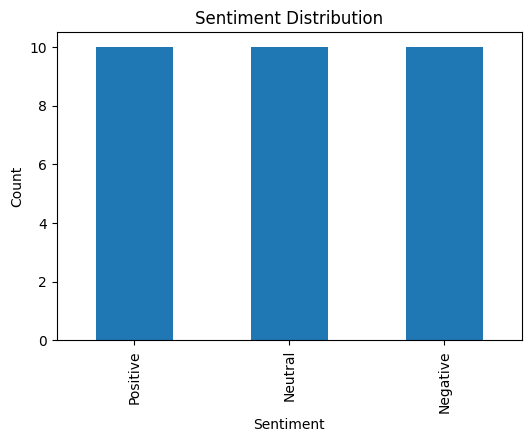

In [33]:
plt.figure(figsize=(6,4))

df["Sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.savefig("sentiment_distribution.png")
plt.show()

### Step 11: Word Cloud

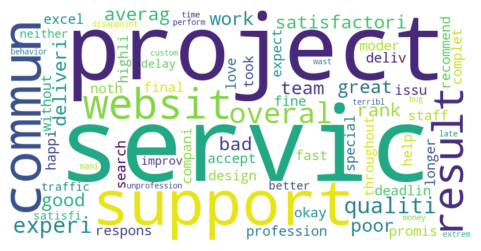

In [35]:
from wordcloud import WordCloud

text = " ".join(df["Cleaned_Text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(6,3))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")

plt.savefig("wordcloud.png", bbox_inches="tight")
plt.show()

### Step 12: Train-Test Split

In [26]:
y = df["Sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
print(X_train.shape)
print(X_test.shape)

(24, 69)
(6, 69)


### Step 13: Train Naive Bayes

In [29]:
model = MultinomialNB()

model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


### Step 14: Predictions

In [30]:
predictions = model.predict(X_test)

print(predictions)

['Positive' 'Negative' 'Neutral' 'Negative' 'Negative' 'Neutral']


### Step 15: Accuracy

In [31]:
accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.0


### Step 16: Conclusion

The customer feedback dataset was analyzed using NLP techniques.
Text cleaning, tokenization, stemming, and TF-IDF vectorization were applied.
A Naive Bayes model was trained for sentiment classification.
The project successfully generated sentiment insights and visualizations.